# FOMC Announcements and SPY Price Discovery

**Group 12 — Quantitative Methods for Finance (TCH442)**  
**Sample:** 2015–2025 | **Frequency:** Daily | **Main estimator:** OLS with Newey–West/HAC standard errors

## Objective

This notebook prepares the complete research dataset and tests whether scheduled FOMC announcement days alter the relationship between SPY's overnight and intraday returns.

The analysis is **associational, not causal**. FOMC decisions respond to macroeconomic conditions that can also affect financial markets.

### Success criteria

1. Build a reproducible, validated market–FOMC dataset.
2. Estimate the three pre-specified models with HAC inference.
3. Produce an event-window visualization and robustness checks.
4. Interpret statistical and economic significance next to each result.

## Research design

For trading day (t):

$$r^{ON}_t=\ln(Open_t/Close_{t-1}), \qquad
r^{ID}_t=\ln(Close_t/Open_t).$$

The primary model is

$$r^{ID}_t=\alpha+\beta r^{ON}_t+\gamma FOMC_t
+\delta(r^{ON}_t\times FOMC_t)+\theta'Controls_t+\varepsilon_t.$$

- ‎(eta): continuation/reversal on ordinary days.
- ‎(gamma): FOMC-day shift when overnight return equals zero.
- ‎(delta): change in the overnight–intraday relationship on FOMC days.

Models 2 and 3 respectively examine absolute intraday returns and differences among `hike`, `cut`, and `hold` decisions.

## 1. Setup and reproducibility

In [1]:
from io import StringIO
from pathlib import Path
import re
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import statsmodels.formula.api as smf
import yfinance as yf
from bs4 import BeautifulSoup
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
plt.style.use("seaborn-v0_8-whitegrid")

SEED = 12
np.random.seed(SEED)

START_DATE = "2015-01-01"
END_DATE = "2025-12-31"
DOWNLOAD_START = "2014-12-15"  # supplies the prior close for the first return
DOWNLOAD_END = "2026-01-02"    # yfinance end date is exclusive
HAC_LAGS = 5
REFRESH_DATA = False

PROJECT_ROOT = Path.cwd()
RAW_DIR = PROJECT_ROOT / "data/raw"
PROCESSED_DIR = PROJECT_ROOT / "data/processed"
FIGURE_DIR = PROJECT_ROOT / "outputs/figures"
TABLE_DIR = PROJECT_ROOT / "outputs/tables"
for directory in [RAW_DIR, PROCESSED_DIR, FIGURE_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("yfinance:", yf.__version__)
print("pandas:", pd.__version__)

Project root: /Users/admin/Documents/TCH442_Group12/fomc-price-discovery/output/jupyter-notebook
yfinance: 0.2.66
pandas: 2.2.3


## 2. Download market data

SPY is downloaded with `auto_adjust=True`, so its Open and Close fields are adjusted consistently for corporate actions. Dividend amounts are retained separately to support the ex-dividend robustness check. VIX is used only as a lagged control for prevailing market uncertainty.

Raw downloads are cached in `data/raw/`; set `REFRESH_DATA=True` to download them again.

In [2]:
spy_path = RAW_DIR / "spy_daily_2014_2025.csv"
vix_path = RAW_DIR / "vix_daily_2014_2025.csv"

def download_one(ticker):
    frame = yf.download(
        ticker,
        start=DOWNLOAD_START,
        end=DOWNLOAD_END,
        auto_adjust=True,
        actions=True,
        progress=False,
        threads=False,
        multi_level_index=False,
    )
    if frame.empty:
        raise RuntimeError(f"No data returned for {ticker}.")
    frame.index = pd.to_datetime(frame.index).tz_localize(None)
    frame.index.name = "Date"
    return frame

if REFRESH_DATA or not spy_path.exists():
    spy_raw = download_one("SPY")
    spy_raw.to_csv(spy_path)
else:
    spy_raw = pd.read_csv(spy_path, parse_dates=["Date"], index_col="Date")

if REFRESH_DATA or not vix_path.exists():
    vix_raw = download_one("^VIX")
    vix_raw.to_csv(vix_path)
else:
    vix_raw = pd.read_csv(vix_path, parse_dates=["Date"], index_col="Date")

market_check = pd.DataFrame({
    "first_date": [spy_raw.index.min(), vix_raw.index.min()],
    "last_date": [spy_raw.index.max(), vix_raw.index.max()],
    "rows": [len(spy_raw), len(vix_raw)],
    "missing_close": [spy_raw["Close"].isna().sum(), vix_raw["Close"].isna().sum()],
}, index=["SPY", "VIX"])
display(market_check)

,first_date,last_date,rows,missing_close
SPY,2014-12-15,2025-12-31,2778,0
VIX,2014-12-15,2025-12-31,2778,0


## 3. Build the scheduled FOMC calendar

Sources:

- [Federal Reserve historical material by year](https://www.federalreserve.gov/monetarypolicy/fomc_historical_year.htm), used for 2015–2020.
- [Federal Reserve meeting calendars](https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm), used for 2021–2025.
The parser keeps regular meetings with a published statement and excludes entries labeled `unscheduled`, `cancelled`, or `notation vote`. Scheduled rate-change dates and magnitudes are recorded explicitly from the Federal Reserve statements so the classification remains transparent and auditable without relying on a third-party API.

In [3]:
FED_BASE = "https://www.federalreserve.gov"
HEADERS = {"User-Agent": "TCH442 academic research project (Group 12)"}

def resilient_get(url, attempts=3, timeout=90):
    last_error = None
    for attempt in range(1, attempts + 1):
        try:
            response = requests.get(url, headers=HEADERS, timeout=timeout)
            response.raise_for_status()
            return response
        except requests.RequestException as error:
            last_error = error
            if attempt < attempts:
                time.sleep(2 * attempt)
    raise RuntimeError(f"Download failed after {attempts} attempts: {url}") from last_error

def get_soup(url):
    response = resilient_get(url)
    return BeautifulSoup(response.text, "html.parser")

def statement_date_from_link(link):
    match = re.search(r"monetary(\d{8})a\.htm", link.get("href", ""))
    return pd.to_datetime(match.group(1), format="%Y%m%d") if match else None

event_rows = []

# Historical year pages: use each regular meeting heading and its next statement link.
for year in range(2015, 2021):
    url = f"{FED_BASE}/monetarypolicy/fomchistorical{year}.htm"
    soup = get_soup(url)
    for heading in soup.select("h5"):
        label = heading.get_text(" ", strip=True)
        label_lower = label.lower()
        excluded = any(word in label_lower for word in ["unscheduled", "cancelled", "notation"])
        if "meeting" not in label_lower or excluded:
            continue
        link = heading.find_next(
            "a", href=re.compile(r"/newsevents/pressreleases/monetary\d{8}a\.htm")
        )
        date = statement_date_from_link(link) if link else None
        if date is not None and date.year == year:
            event_rows.append({"event_date": date, "source_url": url, "meeting_label": label})

# Current calendar page: identify the statement link inside each regular meeting row.
calendar_url = f"{FED_BASE}/monetarypolicy/fomccalendars.htm"
soup = get_soup(calendar_url)
for row in soup.select("div.fomc-meeting"):
    label = row.get_text(" ", strip=True)
    label_lower = label.lower()
    if any(word in label_lower for word in ["unscheduled", "cancelled", "notation vote"]):
        continue
    link = row.find(
        "a", href=re.compile(r"/newsevents/pressreleases/monetary\d{8}a\.htm")
    )
    date = statement_date_from_link(link) if link else None
    if date is not None and 2021 <= date.year <= 2025:
        event_rows.append({"event_date": date, "source_url": calendar_url, "meeting_label": label})

fomc = (
    pd.DataFrame(event_rows)
    .drop_duplicates("event_date")
    .sort_values("event_date")
    .reset_index(drop=True)
)

# Scheduled changes to the target-range upper limit, in percentage points.
# Emergency changes on 2020-03-03 and 2020-03-15 are intentionally omitted.
scheduled_rate_changes = {
    "2015-12-16": 0.25,
    "2016-12-14": 0.25,
    "2017-03-15": 0.25, "2017-06-14": 0.25, "2017-12-13": 0.25,
    "2018-03-21": 0.25, "2018-06-13": 0.25, "2018-09-26": 0.25, "2018-12-19": 0.25,
    "2019-07-31": -0.25, "2019-09-18": -0.25, "2019-10-30": -0.25,
    "2022-03-16": 0.25, "2022-05-04": 0.50, "2022-06-15": 0.75,
    "2022-07-27": 0.75, "2022-09-21": 0.75, "2022-11-02": 0.75, "2022-12-14": 0.50,
    "2023-02-01": 0.25, "2023-03-22": 0.25, "2023-05-03": 0.25, "2023-07-26": 0.25,
    "2024-09-18": -0.50, "2024-11-07": -0.25, "2024-12-18": -0.25,
    "2025-09-17": -0.25, "2025-10-29": -0.25, "2025-12-10": -0.25,
}
scheduled_rate_changes = {
    pd.Timestamp(date): change for date, change in scheduled_rate_changes.items()
}
fomc["rate_change"] = fomc["event_date"].map(scheduled_rate_changes).fillna(0.0)
fomc["decision"] = np.select(
    [fomc["rate_change"] > 1e-9, fomc["rate_change"] < -1e-9],
    ["hike", "cut"],
    default="hold",
)
fomc.to_csv(RAW_DIR / "fomc_scheduled_events_2015_2025.csv", index=False)

calendar_check = fomc.groupby([fomc["event_date"].dt.year, "decision"]).size().unstack(fill_value=0)
display(calendar_check)
print(f"Scheduled events: {len(fomc)}")

assert len(fomc) == 87, "Expected 87 scheduled announcement dates in 2015–2025."
assert fomc["event_date"].is_unique
assert set(scheduled_rate_changes).issubset(set(fomc["event_date"]))

decision,cut,hike,hold
event_date,,,
2015,0,1,7
2016,0,1,7
2017,0,3,5
2018,0,4,4
2019,3,0,5
2020,0,0,7
2021,0,0,8
2022,0,7,1
2023,0,4,4


Scheduled events: 87


## 4. Prepare and validate the analysis dataset

In [4]:
market = spy_raw[["Open", "Close", "Volume", "Dividends"]].copy()
market = market.rename(columns={
    "Open": "spy_open",
    "Close": "spy_close",
    "Volume": "spy_volume",
    "Dividends": "spy_dividend",
})
market["vix_close"] = vix_raw["Close"]

market["overnight_return"] = np.log(market["spy_open"] / market["spy_close"].shift(1))
market["intraday_return"] = np.log(market["spy_close"] / market["spy_open"])
market["close_return"] = np.log(market["spy_close"] / market["spy_close"].shift(1))
market["abs_intraday_return"] = market["intraday_return"].abs()
market["abs_overnight_return"] = market["overnight_return"].abs()
market["lagged_return"] = market["close_return"].shift(1)
market["lagged_abs_return"] = market["close_return"].abs().shift(1)
market["lagged_log_vix"] = np.log(market["vix_close"]).shift(1)
market["ex_dividend"] = (market["spy_dividend"].fillna(0) > 0).astype(int)
market["day_of_week"] = market.index.dayofweek
market["month"] = market.index.month

analysis = market.loc[START_DATE:END_DATE].copy()
event_info = fomc.set_index("event_date")[["decision", "rate_change"]]
analysis = analysis.join(event_info, how="left")
analysis["fomc_day"] = analysis["decision"].notna().astype(int)
for decision in ["hike", "cut", "hold"]:
    analysis[decision] = analysis["decision"].eq(decision).astype(int)

# Standardize the lagged log VIX: its coefficient represents a one-SD change.
analysis["lagged_vix_z"] = (
    analysis["lagged_log_vix"] - analysis["lagged_log_vix"].mean()
) / analysis["lagged_log_vix"].std()

required = [
    "overnight_return", "intraday_return", "close_return",
    "lagged_return", "lagged_abs_return", "lagged_vix_z",
]
analysis = analysis.dropna(subset=required)
analysis.index.name = "Date"
analysis.to_csv(PROCESSED_DIR / "spy_fomc_analysis_2015_2025.csv")

checks = pd.Series({
    "Observations": len(analysis),
    "First trading date": analysis.index.min().date(),
    "Last trading date": analysis.index.max().date(),
    "Scheduled FOMC trading days": int(analysis["fomc_day"].sum()),
    "Hikes": int(analysis["hike"].sum()),
    "Cuts": int(analysis["cut"].sum()),
    "Holds": int(analysis["hold"].sum()),
    "SPY ex-dividend days": int(analysis["ex_dividend"].sum()),
    "Duplicate dates": int(analysis.index.duplicated().sum()),
})
display(checks.to_frame("Value"))

assert analysis.index.is_monotonic_increasing
assert not analysis.index.duplicated().any()
assert analysis[required].notna().all().all()
assert analysis["fomc_day"].sum() == len(fomc)

,Value
Observations,2766
First trading date,2015-01-02
Last trading date,2025-12-31
Scheduled FOMC trading days,87
Hikes,20
Cuts,9
Holds,58
SPY ex-dividend days,44
Duplicate dates,0


## 5. Descriptive statistics

In [5]:
summary = analysis[[
    "overnight_return", "intraday_return", "close_return",
    "abs_intraday_return", "vix_close", "spy_volume",
]].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T
display(summary)

group_summary = analysis.groupby("fomc_day").agg(
    observations=("intraday_return", "size"),
    mean_overnight=("overnight_return", "mean"),
    mean_intraday=("intraday_return", "mean"),
    mean_abs_intraday=("abs_intraday_return", "mean"),
    median_vix=("vix_close", "median"),
)
for col in ["mean_overnight", "mean_intraday", "mean_abs_intraday"]:
    group_summary[col] *= 10_000
group_summary = group_summary.rename(index={0: "Non-FOMC", 1: "FOMC"})
display(group_summary.style.format({
    "observations": "{:,.0f}",
    "mean_overnight": "{:.2f} bp",
    "mean_intraday": "{:.2f} bp",
    "mean_abs_intraday": "{:.2f} bp",
    "median_vix": "{:.2f}",
}))

diff_intraday = group_summary.loc["FOMC", "mean_intraday"] - group_summary.loc["Non-FOMC", "mean_intraday"]
diff_abs = group_summary.loc["FOMC", "mean_abs_intraday"] - group_summary.loc["Non-FOMC", "mean_abs_intraday"]
display(Markdown(
    f"**Descriptive reading.** Scheduled FOMC days have an average intraday return "
    f"that is **{diff_intraday:+.2f} basis points** relative to ordinary days. "
    f"Their average absolute intraday return differs by **{diff_abs:+.2f} basis points**. "
    "These are unconditional differences and should not be interpreted as causal or as regression evidence."
))

,count,mean,std,min,1%,25%,50%,75%,99%,max
overnight_return,"2,766.000000",0.000330,0.007295,-0.110357,-0.020653,-0.002205,0.000617,0.003397,0.018173,0.058624
intraday_return,"2,766.000000",0.000171,0.008448,-0.058277,-0.025224,-0.003309,0.000505,0.004297,0.021501,0.106005
close_return,"2,766.000000",0.000501,0.011230,-0.115887,-0.032680,-0.003709,0.000633,0.005905,0.025914,0.099863
abs_intraday_return,"2,766.000000",0.005675,0.006260,0.000000,0.000039,0.001651,0.003887,0.007609,0.029781,0.106005
vix_close,"2,766.000000",18.331316,7.129529,9.140000,9.702500,13.552500,16.520000,21.247500,42.459499,82.690002
spy_volume,"2,766.000000","86,081,060.484454","43,925,193.016033","20,270,000.000000","32,792,175.000000","58,748,425.000000","75,707,800.000000","99,419,750.000000","257,911,470.000000","507,244,300.000000"


,observations,mean_overnight,mean_intraday,mean_abs_intraday,median_vix
fomc_day,,,,,
Non-FOMC,"2,679",2.85 bp,1.96 bp,56.38 bp,16.53
FOMC,87,16.92 bp,-6.05 bp,68.19 bp,16.36


**Descriptive reading.** Scheduled FOMC days have an average intraday return that is **-8.02 basis points** relative to ordinary days. Their average absolute intraday return differs by **+11.81 basis points**. These are unconditional differences and should not be interpreted as causal or as regression evidence.

## 6. Estimation helpers

All main models use OLS point estimates with HAC/Newey–West standard errors (`maxlags=5`). The HAC correction allows both heteroskedasticity and short-run residual autocorrelation.

In [6]:
def fit_hac(formula, data, lags=HAC_LAGS):
    return smf.ols(formula, data=data).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": lags, "use_correction": True},
    )

def result_table(result, terms):
    ci = result.conf_int()
    table = pd.DataFrame({
        "coefficient": result.params,
        "HAC SE": result.bse,
        "t": result.tvalues,
        "p-value": result.pvalues,
        "CI 2.5%": ci[0],
        "CI 97.5%": ci[1],
    })
    return table.loc[terms]

def significance_text(p):
    if p < 0.01:
        return "statistically significant at 1%"
    if p < 0.05:
        return "statistically significant at 5%"
    if p < 0.10:
        return "marginally significant at 10%"
    return "not statistically significant at 10%"

calendar_controls = "lagged_return + lagged_vix_z + C(day_of_week) + C(month)"

## 7. Model 1 — Overnight–intraday price discovery

In [7]:
formula_1 = (
    "intraday_return ~ overnight_return + fomc_day "
    "+ overnight_return:fomc_day + " + calendar_controls
)
model_1 = fit_hac(formula_1, analysis)
terms_1 = ["overnight_return", "fomc_day", "overnight_return:fomc_day", "lagged_return", "lagged_vix_z"]
table_1 = result_table(model_1, terms_1)
display(table_1)
table_1.to_csv(TABLE_DIR / "model_1_price_discovery.csv")

beta = model_1.params["overnight_return"]
gamma = model_1.params["fomc_day"]
delta = model_1.params["overnight_return:fomc_day"]
p_delta = model_1.pvalues["overnight_return:fomc_day"]
fomc_slope_test = model_1.t_test("overnight_return + overnight_return:fomc_day = 0")
fomc_slope = beta + delta
fomc_slope_p = float(np.asarray(fomc_slope_test.pvalue).squeeze())

normal_pattern = "continuation" if beta > 0 else "reversal"
fomc_pattern = "continuation" if fomc_slope > 0 else "reversal"
display(Markdown(
    f"""### Interpretation — Model 1

- On non-FOMC days, the overnight–intraday slope is **{beta:.3f}**, indicating **{normal_pattern}** on average.
- On FOMC days, the implied slope is **{fomc_slope:.3f}** (linear-combination p-value = **{fomc_slope_p:.3f}**), indicating **{fomc_pattern}**.
- The interaction estimate is **{delta:.3f}** and is **{significance_text(p_delta)}** (p = **{p_delta:.3f}**). This is the direct test of whether the relationship changes on scheduled announcement days.
- Holding controls fixed and evaluating at zero overnight return, the FOMC-day level shift is **{gamma * 10_000:+.2f} basis points**.

The coefficients describe conditional associations. They do not isolate an exogenous monetary-policy shock.
"""
))

,coefficient,HAC SE,t,p-value,CI 2.5%,CI 97.5%
overnight_return,0.006595,0.043939,0.150099,0.880686,-0.079523,0.092714
fomc_day,-0.001279,0.001143,-1.119267,0.263026,-0.003518,0.000961
overnight_return:fomc_day,0.190919,0.243447,0.784231,0.432904,-0.286229,0.668067
lagged_return,-0.044487,0.025284,-1.759528,0.078488,-0.094042,0.005068
lagged_vix_z,0.000267,0.000199,1.340133,0.180202,-0.000123,0.000656


### Interpretation — Model 1

- On non-FOMC days, the overnight–intraday slope is **0.007**, indicating **continuation** on average.
- On FOMC days, the implied slope is **0.198** (linear-combination p-value = **0.413**), indicating **continuation**.
- The interaction estimate is **0.191** and is **not statistically significant at 10%** (p = **0.433**). This is the direct test of whether the relationship changes on scheduled announcement days.
- Holding controls fixed and evaluating at zero overnight return, the FOMC-day level shift is **-12.79 basis points**.

The coefficients describe conditional associations. They do not isolate an exogenous monetary-policy shock.


## 8. Model 2 — Intraday volatility

In [8]:
formula_2 = (
    "abs_intraday_return ~ fomc_day + abs_overnight_return "
    "+ lagged_abs_return + lagged_vix_z + C(day_of_week) + C(month)"
)
model_2 = fit_hac(formula_2, analysis)
terms_2 = ["fomc_day", "abs_overnight_return", "lagged_abs_return", "lagged_vix_z"]
table_2 = result_table(model_2, terms_2)
display(table_2)
table_2.to_csv(TABLE_DIR / "model_2_intraday_volatility.csv")

vol_effect = model_2.params["fomc_day"] * 10_000
vol_p = model_2.pvalues["fomc_day"]
direction = "higher" if vol_effect > 0 else "lower"
display(Markdown(
    f"""### Interpretation — Model 2

After controlling for overnight movement, lagged volatility, VIX and calendar effects, scheduled FOMC days are associated with **{abs(vol_effect):.2f} basis points {direction}** absolute intraday return. The estimate is **{significance_text(vol_p)}** (p = **{vol_p:.3f}**).

This coefficient measures a difference in realized intraday movement, not a structural measure of uncertainty and not a causal treatment effect.
"""
))

,coefficient,HAC SE,t,p-value,CI 2.5%,CI 97.5%
fomc_day,0.001302,0.000681,1.912375,0.055828,-0.000032,0.002636
abs_overnight_return,0.108248,0.043575,2.484201,0.012984,0.022843,0.193652
lagged_abs_return,-0.005923,0.023453,-0.252554,0.800613,-0.051890,0.040044
lagged_vix_z,0.002663,0.000270,9.855834,0.000000,0.002133,0.003192


### Interpretation — Model 2

After controlling for overnight movement, lagged volatility, VIX and calendar effects, scheduled FOMC days are associated with **13.02 basis points higher** absolute intraday return. The estimate is **marginally significant at 10%** (p = **0.056**).

This coefficient measures a difference in realized intraday movement, not a structural measure of uncertainty and not a causal treatment effect.


## 9. Model 3 — Hike, cut, and hold decisions

In [9]:
formula_3 = (
    "intraday_return ~ overnight_return + hike + cut + hold "
    "+ overnight_return:hike + overnight_return:cut + overnight_return:hold "
    "+ " + calendar_controls
)
model_3 = fit_hac(formula_3, analysis)
terms_3 = [
    "overnight_return", "hike", "cut", "hold",
    "overnight_return:hike", "overnight_return:cut", "overnight_return:hold",
]
table_3 = result_table(model_3, terms_3)
display(table_3)
table_3.to_csv(TABLE_DIR / "model_3_decision_types.csv")

interpretation_lines = []
for decision in ["hike", "cut", "hold"]:
    level_bp = model_3.params[decision] * 10_000
    level_p = model_3.pvalues[decision]
    interaction = model_3.params[f"overnight_return:{decision}"]
    interaction_p = model_3.pvalues[f"overnight_return:{decision}"]
    n_events = int(analysis[decision].sum())
    interpretation_lines.append(
        f"- **{decision.title()} ({n_events} events):** conditional intraday shift "
        f"= **{level_bp:+.2f} bp** (p = {level_p:.3f}); slope change "
        f"= **{interaction:+.3f}** (p = {interaction_p:.3f})."
    )

display(Markdown(
    "### Interpretation — Model 3\n\n" + "\n".join(interpretation_lines) +
    "\n\nSubgroup estimates should be interpreted cautiously because the number of "
    "rate changes is much smaller than the number of hold decisions. Hike/cut/hold "
    "also does not measure whether the decision surprised the market."
))

,coefficient,HAC SE,t,p-value,CI 2.5%,CI 97.5%
overnight_return,0.006542,0.043940,0.148892,0.881639,-0.079579,0.092663
hike,-0.003509,0.003217,-1.090818,0.275353,-0.009815,0.002796
cut,-0.004263,0.004826,-0.883297,0.377076,-0.013723,0.005196
hold,-0.000414,0.001127,-0.367592,0.713178,-0.002622,0.001794
overnight_return:hike,1.156751,0.653633,1.769725,0.076773,-0.124347,2.437849
overnight_return:cut,1.223933,2.169896,0.564051,0.572719,-3.028985,5.476850
overnight_return:hold,-0.024835,0.260381,-0.095378,0.924014,-0.535171,0.485502


### Interpretation — Model 3

- **Hike (20 events):** conditional intraday shift = **-35.09 bp** (p = 0.275); slope change = **+1.157** (p = 0.077).
- **Cut (9 events):** conditional intraday shift = **-42.63 bp** (p = 0.377); slope change = **+1.224** (p = 0.573).
- **Hold (58 events):** conditional intraday shift = **-4.14 bp** (p = 0.713); slope change = **-0.025** (p = 0.924).

Subgroup estimates should be interpreted cautiously because the number of rate changes is much smaller than the number of hold decisions. Hike/cut/hold also does not measure whether the decision surprised the market.

## 10. Event window `[-2, +2]`

,events,mean_overnight,mean_intraday,mean_close,se_close,cumulative_mean_close,mean_overnight_bp,mean_intraday_bp,mean_close_bp
relative_day,,,,,,,,,
-2,87,-0.000653,0.000918,0.000265,0.000937,0.000265,-6.528978,9.183399,2.654422
-1,87,0.001164,-0.000038,0.001126,0.000853,0.001392,11.641213,-0.377907,11.263306
0,87,0.001692,-0.000605,0.001086,0.001160,0.002478,16.917308,-6.054258,10.863049
1,87,-0.000349,-0.001298,-0.001647,0.001288,0.000831,-3.486041,-12.984672,-16.470713
2,87,0.000390,-0.001427,-0.001037,0.001156,-0.000206,3.898973,-14.271676,-10.372704


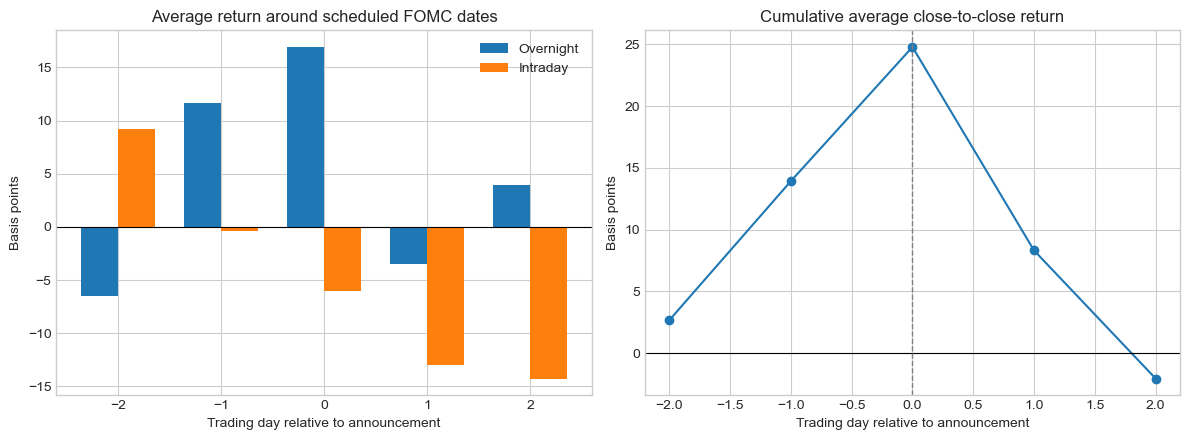

**Event-window reading.** Across **87 scheduled events**, announcement-day average overnight return is **+16.92 bp** and average intraday return is **-6.05 bp**. The plot is descriptive: overlapping macroeconomic news and cross-event dependence are not removed.

In [10]:
event_frames = []
for event_date in fomc["event_date"]:
    if event_date not in analysis.index:
        continue
    event_position = analysis.index.get_loc(event_date)
    if event_position < 2 or event_position + 2 >= len(analysis):
        continue
    window = analysis.iloc[event_position - 2:event_position + 3][
        ["overnight_return", "intraday_return", "close_return"]
    ].copy()
    window["relative_day"] = range(-2, 3)
    window["event_date"] = event_date
    event_frames.append(window.reset_index())

event_panel = pd.concat(event_frames, ignore_index=True)
event_summary = event_panel.groupby("relative_day").agg(
    events=("event_date", "nunique"),
    mean_overnight=("overnight_return", "mean"),
    mean_intraday=("intraday_return", "mean"),
    mean_close=("close_return", "mean"),
    se_close=("close_return", "sem"),
)
event_summary["cumulative_mean_close"] = event_summary["mean_close"].cumsum()
display(event_summary.assign(
    mean_overnight_bp=event_summary["mean_overnight"] * 10_000,
    mean_intraday_bp=event_summary["mean_intraday"] * 10_000,
    mean_close_bp=event_summary["mean_close"] * 10_000,
))
event_summary.to_csv(TABLE_DIR / "event_window_summary.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
width = 0.36
x = event_summary.index.to_numpy()
axes[0].bar(x - width/2, event_summary["mean_overnight"] * 10_000, width, label="Overnight")
axes[0].bar(x + width/2, event_summary["mean_intraday"] * 10_000, width, label="Intraday")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set(title="Average return around scheduled FOMC dates", xlabel="Trading day relative to announcement", ylabel="Basis points")
axes[0].legend()

axes[1].plot(x, event_summary["cumulative_mean_close"] * 10_000, marker="o")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].axvline(0, color="gray", linestyle="--", linewidth=1)
axes[1].set(title="Cumulative average close-to-close return", xlabel="Trading day relative to announcement", ylabel="Basis points")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "fomc_event_window.png", dpi=180, bbox_inches="tight")
plt.show()

day0 = event_summary.loc[0]
display(Markdown(
    f"**Event-window reading.** Across **{int(day0['events'])} scheduled events**, "
    f"announcement-day average overnight return is **{day0['mean_overnight']*10_000:+.2f} bp** "
    f"and average intraday return is **{day0['mean_intraday']*10_000:+.2f} bp**. "
    "The plot is descriptive: overlapping macroeconomic news and cross-event dependence are not removed."
))

## 11. Pre-specified robustness checks

In [11]:
# Check A: remove SPY ex-dividend dates.
model_no_dividend = fit_hac(formula_1, analysis.loc[analysis["ex_dividend"] == 0])

# Check B: estimate the baseline separately before and after 2020.
model_pre2020 = fit_hac(formula_1, analysis.loc[:"2019-12-31"])
model_post2020 = fit_hac(formula_1, analysis.loc["2020-01-01":])

key_terms = ["fomc_day", "overnight_return:fomc_day"]
robustness_rows = []
for label, result in {
    "Baseline 2015–2025": model_1,
    "Exclude ex-dividend dates": model_no_dividend,
    "2015–2019": model_pre2020,
    "2020–2025": model_post2020,
}.items():
    for term in key_terms:
        robustness_rows.append({
            "sample": label,
            "term": term,
            "coefficient": result.params[term],
            "HAC SE": result.bse[term],
            "p-value": result.pvalues[term],
            "n": int(result.nobs),
        })

robustness = pd.DataFrame(robustness_rows)
display(robustness)
robustness.to_csv(TABLE_DIR / "model_1_robustness.csv", index=False)

baseline_delta = model_1.params["overnight_return:fomc_day"]
no_div_delta = model_no_dividend.params["overnight_return:fomc_day"]
pre_delta = model_pre2020.params["overnight_return:fomc_day"]
post_delta = model_post2020.params["overnight_return:fomc_day"]

same_div_sign = np.sign(baseline_delta) == np.sign(no_div_delta)
same_period_sign = np.sign(pre_delta) == np.sign(post_delta)
display(Markdown(
    f"""### Interpretation — robustness

- Removing ex-dividend dates **{'preserves' if same_div_sign else 'changes'}** the sign of the key interaction: baseline **{baseline_delta:+.3f}**, no-dividend **{no_div_delta:+.3f}**.
- The interaction is **{pre_delta:+.3f}** in 2015–2019 and **{post_delta:+.3f}** in 2020–2025; the signs are **{'consistent' if same_period_sign else 'not consistent'}** across subsamples.
- Emergency 2020 decisions were already excluded when constructing the scheduled-event calendar.

Subsample differences are evidence of possible instability, not proof of a structural break. The limited number of FOMC observations means p-values can be sensitive to the chosen sample.
"""
))

,sample,term,coefficient,HAC SE,p-value,n
0,Baseline 2015–2025,fomc_day,-0.001279,0.001143,0.263026,2766
1,Baseline 2015–2025,overnight_return:fomc_day,0.190919,0.243447,0.432904,2766
2,Exclude ex-dividend dates,fomc_day,-0.001285,0.001148,0.263105,2722
3,Exclude ex-dividend dates,overnight_return:fomc_day,0.172627,0.243829,0.478954,2722
4,2015–2019,fomc_day,-0.001165,0.001155,0.312961,1258
5,2015–2019,overnight_return:fomc_day,-0.136131,0.639661,0.831470,1258
6,2020–2025,fomc_day,-0.001529,0.001947,0.432260,1508
7,2020–2025,overnight_return:fomc_day,0.285424,0.285077,0.316721,1508


### Interpretation — robustness

- Removing ex-dividend dates **preserves** the sign of the key interaction: baseline **+0.191**, no-dividend **+0.173**.
- The interaction is **-0.136** in 2015–2019 and **+0.285** in 2020–2025; the signs are **not consistent** across subsamples.
- Emergency 2020 decisions were already excluded when constructing the scheduled-event calendar.

Subsample differences are evidence of possible instability, not proof of a structural break. The limited number of FOMC observations means p-values can be sensitive to the chosen sample.


## 12. Consolidated findings

In [12]:
delta_p = model_1.pvalues["overnight_return:fomc_day"]
fomc_vol_p = model_2.pvalues["fomc_day"]

h2 = "support" if delta_p < 0.05 else "do not support"
h3 = "supported" if (model_2.params["fomc_day"] > 0 and fomc_vol_p < 0.05) else "not supported at the 5% level"

final_findings = pd.DataFrame({
    "Question": [
        "Does the overnight–intraday slope change on FOMC days?",
        "Are absolute intraday returns higher on FOMC days?",
        "Is the key interaction stable across the two subsamples?",
    ],
    "Evidence": [
        f"delta={delta:+.3f}, p={delta_p:.3f}",
        f"effect={vol_effect:+.2f} bp, p={fomc_vol_p:.3f}",
        f"2015–19={pre_delta:+.3f}; 2020–25={post_delta:+.3f}",
    ],
    "Assessment": ["supported at 5%" if delta_p < 0.05 else "not supported at 5%", h3, "same sign" if same_period_sign else "different signs"],
})
display(final_findings)

display(Markdown(
    f"""## Overall interpretation

The main interaction between overnight return and the scheduled-FOMC indicator is **{delta:+.3f}** with a HAC p-value of **{delta_p:.3f}**. Therefore, the data **{h2}** the claim that scheduled announcements change the overnight–intraday relationship at the conventional 5% threshold.

Model 2 estimates an FOMC-day difference of **{vol_effect:+.2f} basis points** in absolute intraday return (p = **{fomc_vol_p:.3f}**), so the hypothesis that scheduled meetings are associated with higher intraday movement is **{h3}**.

These conclusions should emphasize effect sizes, uncertainty and robustness—not only statistical significance. In particular, decision type is an imperfect proxy for monetary-policy news because a hike or cut may have been fully anticipated before the statement.
"""
))

print("Saved processed dataset:", PROCESSED_DIR / "spy_fomc_analysis_2015_2025.csv")
print("Saved model tables:", TABLE_DIR)
print("Saved event-study figure:", FIGURE_DIR / "fomc_event_window.png")

,Question,Evidence,Assessment
0,Does the overnight–intraday slope change on FO...,"delta=+0.191, p=0.433",not supported at 5%
1,Are absolute intraday returns higher on FOMC d...,"effect=+13.02 bp, p=0.056",not supported at the 5% level
2,Is the key interaction stable across the two s...,2015–19=-0.136; 2020–25=+0.285,different signs


## Overall interpretation

The main interaction between overnight return and the scheduled-FOMC indicator is **+0.191** with a HAC p-value of **0.433**. Therefore, the data **do not support** the claim that scheduled announcements change the overnight–intraday relationship at the conventional 5% threshold.

Model 2 estimates an FOMC-day difference of **+13.02 basis points** in absolute intraday return (p = **0.056**), so the hypothesis that scheduled meetings are associated with higher intraday movement is **not supported at the 5% level**.

These conclusions should emphasize effect sizes, uncertainty and robustness—not only statistical significance. In particular, decision type is an imperfect proxy for monetary-policy news because a hike or cut may have been fully anticipated before the statement.


Saved processed dataset: /Users/admin/Documents/TCH442_Group12/fomc-price-discovery/output/jupyter-notebook/data/processed/spy_fomc_analysis_2015_2025.csv
Saved model tables: /Users/admin/Documents/TCH442_Group12/fomc-price-discovery/output/jupyter-notebook/outputs/tables
Saved event-study figure: /Users/admin/Documents/TCH442_Group12/fomc-price-discovery/output/jupyter-notebook/outputs/figures/fomc_event_window.png


## Next steps before the final report

- Manually audit all 87 event dates against the Federal Reserve source links saved in the event CSV.
- Report the limited number of cut/hike observations when interpreting Model 3.
- Add 2–4 literature sources and distinguish scheduled announcements from true policy surprises.
- Freeze package versions in `requirements.txt` after the final clean run.
- Treat the output as evidence about conditional associations, not causal effects.